# Modelo Predictivo de Accidentes Automovilísticos
## Universidad Tecnológica de Panamá — Maestría en Analítica de Datos
### Proyecto Integrador II — 2026

## Nota sobre el dataset
El dataset US Accidents fue filtrado para el estado de **Florida**,
seleccionado por su similitud climática y estructural con Panamá
(clima subtropical, infraestructura mixta urbana/rural, geografía costera).
La granularidad geográfica se trabaja a nivel de **County** y **City**.

**Enfoque del modelo — Dos etapas:**
- **Etapa 1:** Estimar la *probabilidad de ocurrencia* de un accidente por zona geográfica
- **Etapa 2:** Dado que ocurre un accidente, predecir su *nivel de severidad* (Low / Moderate / High)

---
## 1. Setup & Carga de Datos

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [109]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

# format all floating-point numbers to 2 decimal places when displaying them in tables
pd.set_option('display.float_format', lambda x: '%.2f' % x)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [110]:
csv_file = '/content/drive/MyDrive/UTP/2024/s107_Proyector_Integrador_1/final_project/notebooks/data/US_Accidents_FL.csv'

traffic_accidents_raw = pd.read_csv(csv_file) # leemos el dataset


---
## 2. Exploración Inicial (EDA)

In [113]:
# Columnas disponibles
traffic_accidents_raw.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [114]:
print(f"Total columnas: {len(traffic_accidents_raw.columns)}")
print(f"Total registros: {len(traffic_accidents_raw):,}")

Total columnas: 46
Total registros: 880,192


In [117]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

numeric_df = traffic_accidents_raw.select_dtypes(include=numerics)
len(numeric_df.columns)

13

In [115]:
traffic_accidents_raw.head(3)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-116062,Source2,3,2016-11-30 15:36:03,2016-11-30 17:09:22,27.98,-82.33,NaN,NaN,0.01,Queueing traffic and two left lane blocked due to accident on I-75 Southbound after Exits 260 260A 260B FL-574 Dr Martin Luther King Jr Blvd.,E Dr Martin Luther King Jr Blvd,Tampa,Hillsborough,FL,33610,US,US/Eastern,KVDF,2016-11-30 15:35:00,80.60,NaN,70.00,29.94,10.00,SSW,5.80,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
1,A-116063,Source2,3,2016-11-30 16:25:35,2016-11-30 17:12:25,27.98,-82.33,NaN,NaN,0.01,Queueing traffic and 2 left lane closed due to accident on I-75 Southbound at Exits 260 260A 260B FL-574 Dr Martin Luther King Jr Blvd.,E Dr Martin Luther King Jr Blvd,Tampa,Hillsborough,FL,33610,US,US/Eastern,KVDF,2016-11-30 16:35:00,80.60,NaN,65.00,29.94,10.00,WSW,6.90,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
2,A-116064,Source2,2,2016-11-30 16:40:31,2016-11-30 17:10:19,25.63,-80.37,NaN,NaN,0.01,Accident on FL-992 152nd St at Lincoln Blvd.,SW 152nd St,Miami,Miami-Dade,FL,33157-1147,US,US/Eastern,KTMB,2016-11-30 16:53:00,80.10,NaN,71.00,29.96,10.00,SE,9.20,NaN,Mostly Cloudy,False,False,True,False,False,False,False,False,False,True,False,True,False,Day,Day,Day,Day


In [118]:
traffic_accidents_raw.shape

(880192, 46)

In [119]:
traffic_accidents_raw.dtypes

,0
ID,object
Source,object
Severity,int64
Start_Time,object
End_Time,object
Start_Lat,float64
Start_Lng,float64
End_Lat,float64
End_Lng,float64
Distance(mi),float64


---
## 3. Limpieza de Datos

In [120]:
# Identificar valores nulos
missing_values = traffic_accidents_raw.isnull().sum()
missing_values[missing_values > 0]

,0
End_Lat,282640
End_Lng,282640
Street,1251
City,33
Zipcode,765
Timezone,766
Airport_Code,1007
Weather_Timestamp,5458
Temperature(F),13828
Wind_Chill(F),189358


In [121]:
# Tratamiento de valores nulos
# Numéricas → mediana | Categóricas → moda
for col in number_columns:
    traffic_accidents_raw[col] = traffic_accidents_raw[col].fillna(
        traffic_accidents_raw[col].median()
    )

for col in categorical_columns:
    traffic_accidents_raw[col] = traffic_accidents_raw[col].fillna(
        traffic_accidents_raw[col].mode()[0]
    )

print(f"Nulos restantes: {traffic_accidents_raw.isnull().sum().sum()}")

Nulos restantes: 0


In [122]:
traffic_accidents_raw.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00
mean,2.14,27.53,-81.48,27.41,-81.38,0.53,75.40,75.63,71.37,30.02,9.52,8.46,0.01
std,0.41,1.56,1.44,1.29,1.20,1.67,10.38,9.62,17.12,0.16,1.68,5.04,0.06
min,1.00,24.55,-87.56,24.57,-87.62,0.00,-58.00,-80.00,1.00,0.00,0.00,0.00,0.00
25%,2.00,25.93,-82.25,26.07,-81.50,0.00,70.00,73.00,59.00,29.94,10.00,5.00,0.00
50%,2.00,27.76,-81.40,27.41,-81.33,0.10,77.00,77.00,72.00,30.02,10.00,8.00,0.00
75%,2.00,28.53,-80.32,28.19,-80.38,0.38,82.00,81.00,86.00,30.09,10.00,12.00,0.00
max,4.00,31.00,-80.04,31.01,-80.04,148.36,174.00,174.00,100.00,58.63,72.00,984.00,9.98


In [123]:
# Valores únicos por columna
unique_values_df = pd.DataFrame({
    'Columna': traffic_accidents_raw.columns,
    'Valores Únicos': [traffic_accidents_raw[col].nunique() for col in traffic_accidents_raw.columns]
})
display(unique_values_df)

,Columna,Valores Únicos
0,ID,880192
1,Source,3
2,Severity,4
3,Start_Time,662141
4,End_Time,759762
5,Start_Lat,264142
6,Start_Lng,249042
7,End_Lat,171907
8,End_Lng,169816
9,Distance(mi),10630


In [124]:
# Verificar duplicados
print(f"Filas duplicadas: {traffic_accidents_raw.duplicated().sum()}")

Filas duplicadas: 0


In [44]:
traffic_accidents_raw.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00
mean,2.14,27.53,-81.48,27.41,-81.38,0.53,75.40,75.63,71.37,30.02,9.52,8.46,0.01
std,0.41,1.56,1.44,1.29,1.20,1.67,10.38,9.62,17.12,0.16,1.68,5.04,0.06
min,1.00,24.55,-87.56,24.57,-87.62,0.00,-58.00,-80.00,1.00,0.00,0.00,0.00,0.00
25%,2.00,25.93,-82.25,26.07,-81.50,0.00,70.00,73.00,59.00,29.94,10.00,5.00,0.00
50%,2.00,27.76,-81.40,27.41,-81.33,0.10,77.00,77.00,72.00,30.02,10.00,8.00,0.00
75%,2.00,28.53,-80.32,28.19,-80.38,0.38,82.00,81.00,86.00,30.09,10.00,12.00,0.00
max,4.00,31.00,-80.04,31.01,-80.04,148.36,174.00,174.00,100.00,58.63,72.00,984.00,9.98


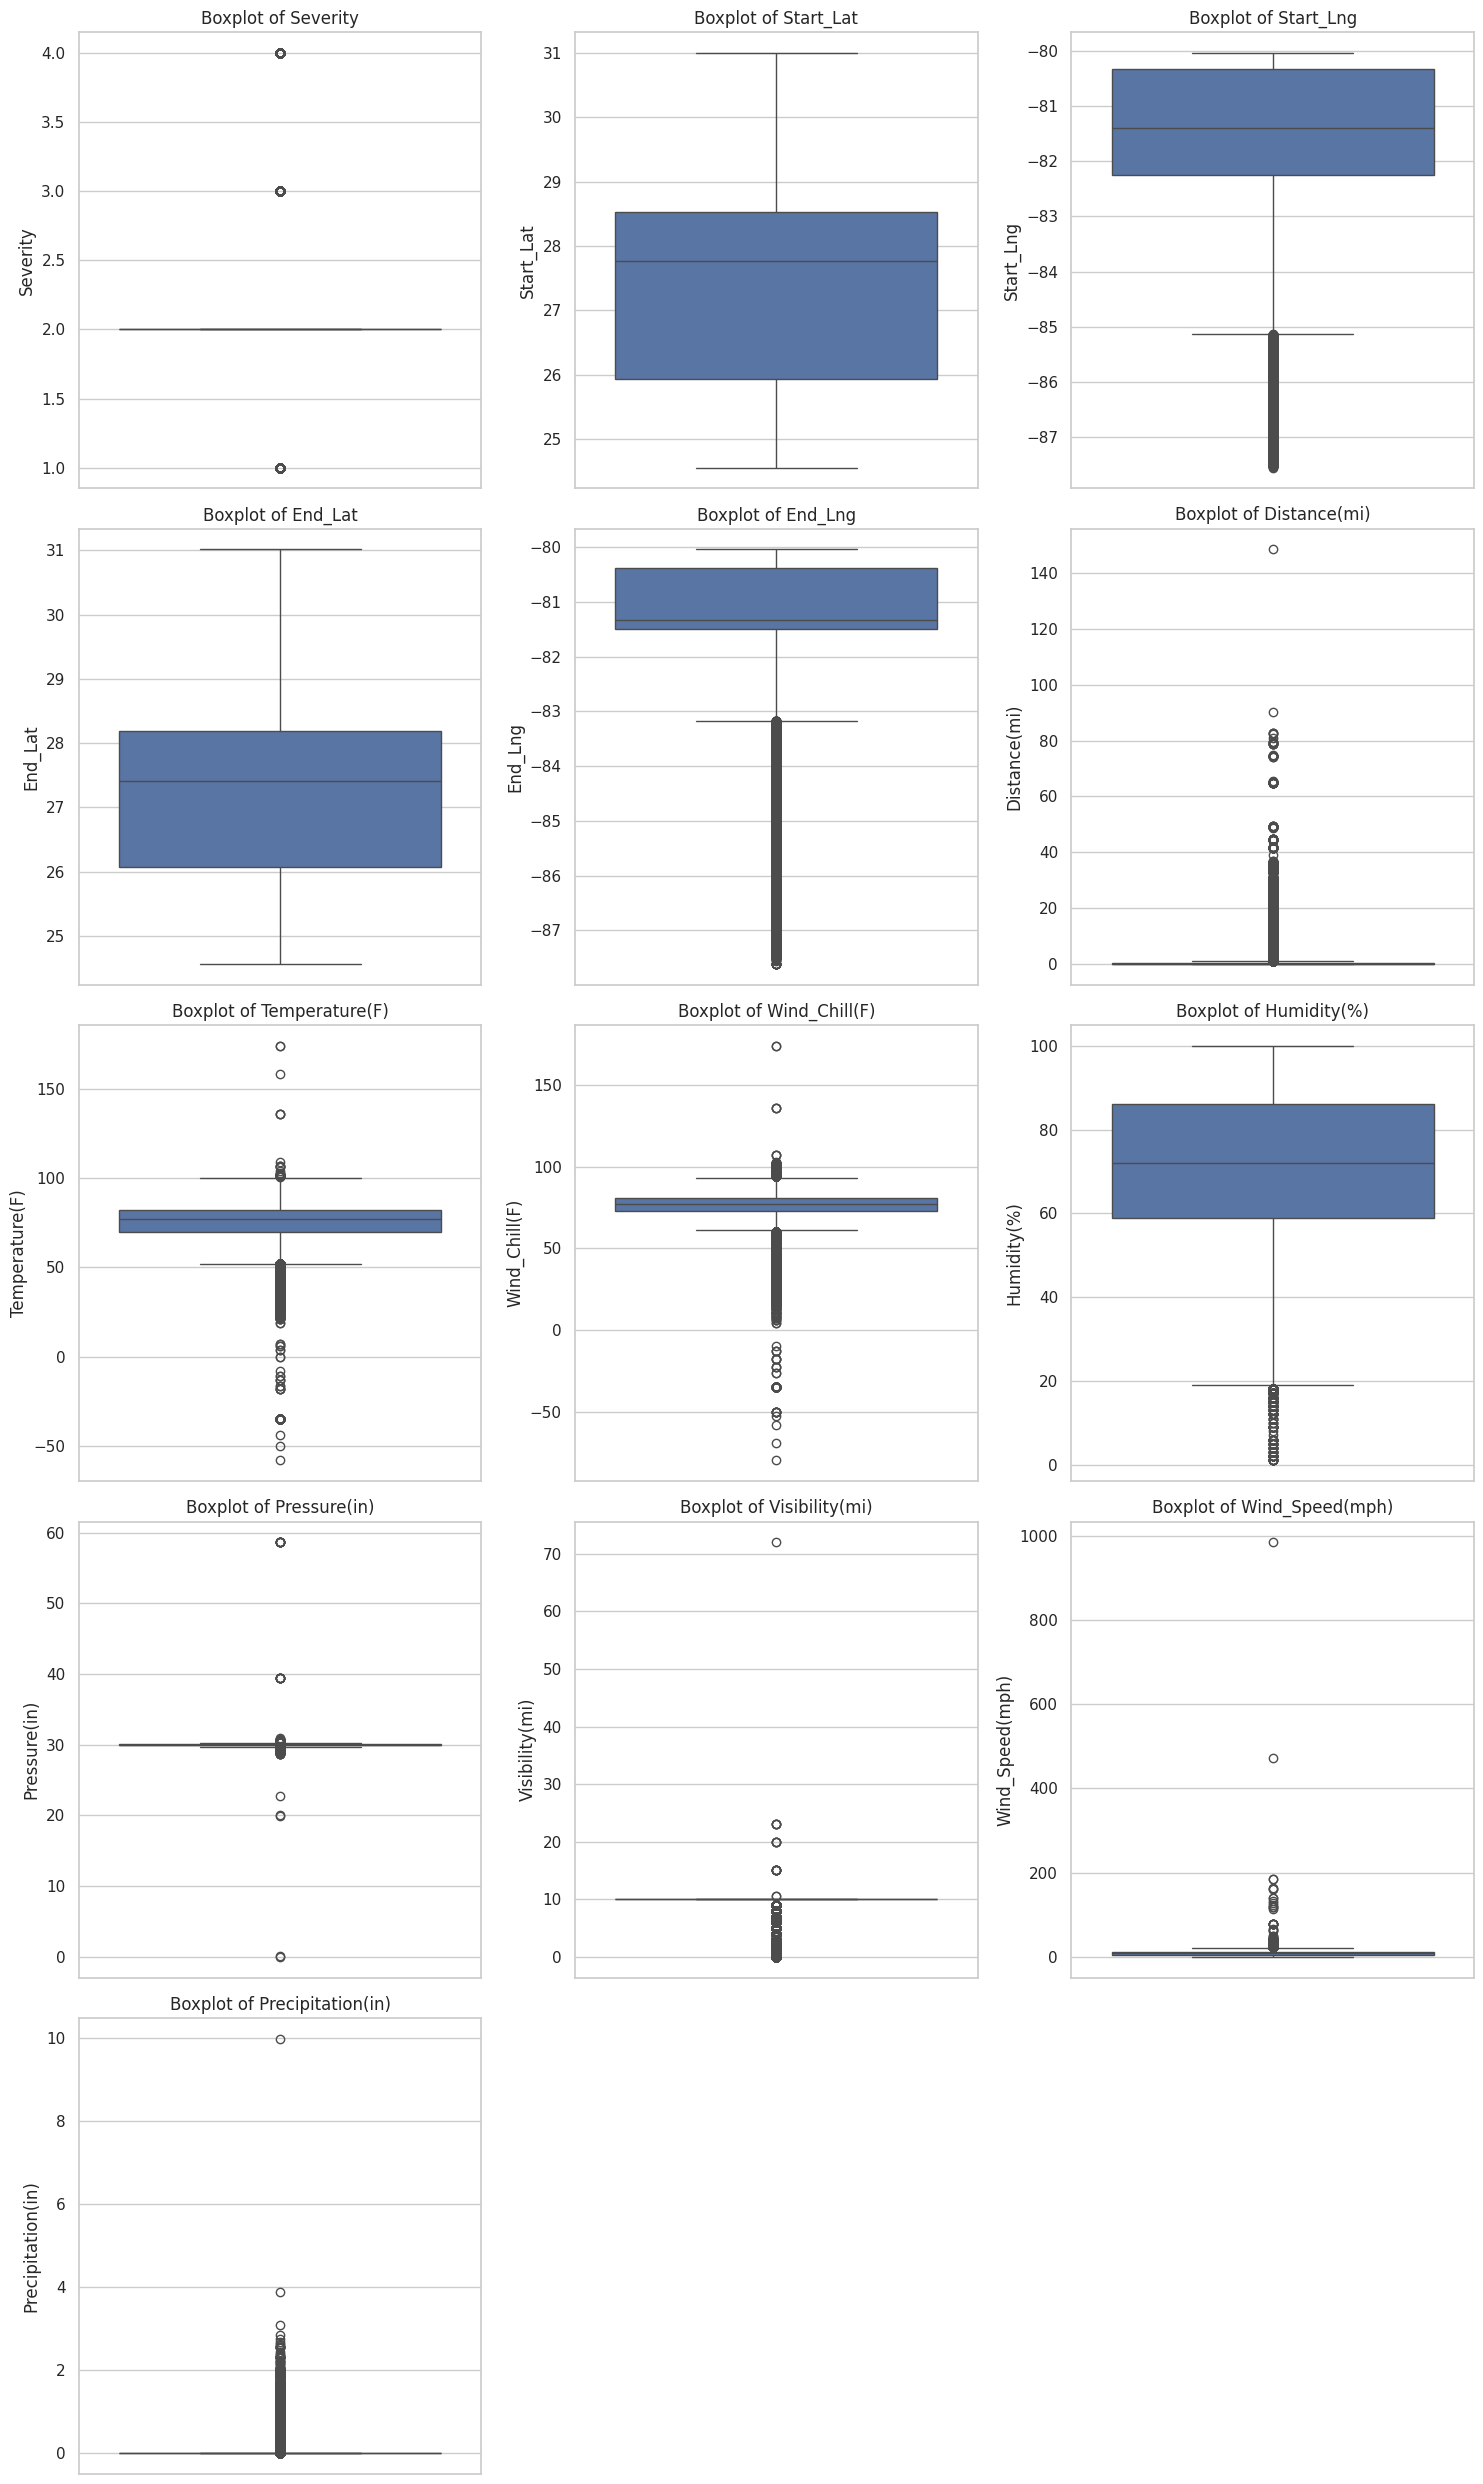

In [125]:
# Boxplots para detección de outliers
num_features = len(traffic_accidents_raw.select_dtypes(include=['float64', 'int64']).columns)
fig, axes = plt.subplots(nrows=(num_features // 3) + 1, ncols=3,
                         figsize=(15, 5 * ((num_features // 3) + 1)))
axes = axes.flatten()

for i, feature in enumerate(traffic_accidents_raw.select_dtypes(include=['float64', 'int64']).columns):
    sns.boxplot(y=traffic_accidents_raw[feature], ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [126]:
# Remoción de outliers con método IQR
cleaned_df = traffic_accidents_raw.copy()

for feature in cleaned_df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = cleaned_df[feature].quantile(0.25)
    Q3 = cleaned_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    cleaned_df = cleaned_df[
        (cleaned_df[feature] >= lower_bound) &
        (cleaned_df[feature] <= upper_bound)
    ]

print(f"Registros antes: {len(traffic_accidents_raw):,}")
print(f"Registros después de IQR: {len(cleaned_df):,}")

Registros antes: 880,192
Registros después de IQR: 505,471


---
## 4. EDA General

In [127]:
# Distribución de variables categóricas (Top 10 por columna)
dist_cat_columns = traffic_accidents_raw[[
    'Street', 'City', 'County',
    # 'State',  # comentado: dataset filtrado a Florida únicamente
    'Wind_Direction', 'Weather_Condition',
    'Sunrise_Sunset', 'Civil_Twilight',
    'Nautical_Twilight', 'Astronomical_Twilight'
]]

all_frecuencias = {}
for column in dist_cat_columns:
    top_10_freq = traffic_accidents_raw[column].str.strip().value_counts()[:10]
    all_frecuencias[column] = pd.DataFrame({
        'Columna': column,
        'Valor': top_10_freq.index,
        'Frecuencia': top_10_freq.values
    })

frecuencias_df = pd.concat(all_frecuencias.values(), ignore_index=True)

In [128]:
# Visualización de frecuencias categóricas
for columna in frecuencias_df['Columna'].unique():
    df_columna = frecuencias_df[frecuencias_df['Columna'] == columna]
    fig = px.bar(
        y=df_columna['Frecuencia'],
        x=df_columna['Valor'],
        color=df_columna['Valor'],
        color_discrete_sequence=px.colors.sequential.PuBuGn,
        text=df_columna['Frecuencia'],
        template='seaborn'
    )
    fig.update_layout(
        title_text=f'Distribución de Frecuencias — "{columna}"',
        height=700, width=1800,
        xaxis_title=columna, yaxis_title='Frecuencia',
        font=dict(size=17)
    )
    fig.show()

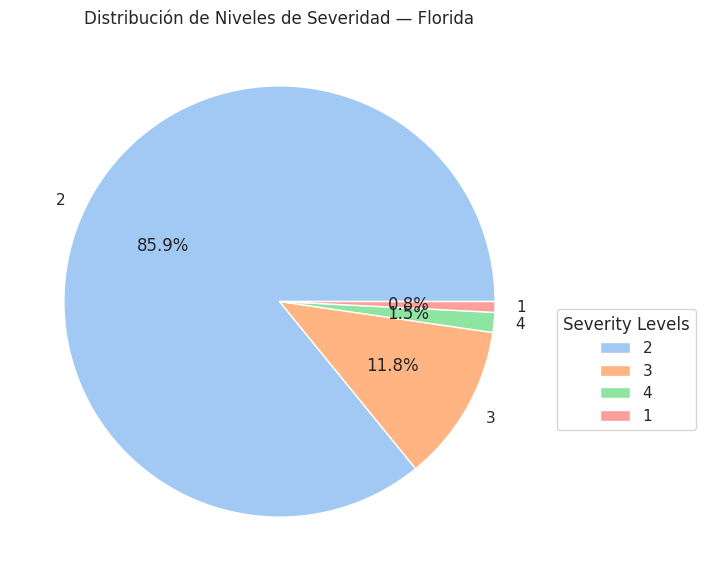

In [129]:
# Distribución de Severidad
severity_count = traffic_accidents_raw['Severity'].value_counts()

sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 7))
pastel_colors = sns.color_palette('pastel', len(severity_count))
plt.pie(severity_count, labels=severity_count.index,
        autopct='%1.1f%%', colors=pastel_colors)
plt.legend(title='Severity Levels', loc='best', bbox_to_anchor=(1, 0.5))
plt.title('Distribución de Niveles de Severidad — Florida')
plt.show()

---
## 5. ETAPA 1 — Probabilidad de Ocurrencia

### 5.1 Análisis Temporal

In [131]:
# Extraer variables temporales
traffic_accidents_raw['Start_Time'] = pd.to_datetime(
    traffic_accidents_raw['Start_Time'], errors='coerce'
)
traffic_accidents_raw['Hour']      = traffic_accidents_raw['Start_Time'].dt.hour
traffic_accidents_raw['DayOfWeek'] = traffic_accidents_raw['Start_Time'].dt.day_name()
traffic_accidents_raw['Month']     = traffic_accidents_raw['Start_Time'].dt.month_name()

day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# Por hora
hourly = traffic_accidents_raw.groupby('Hour').size().reset_index(name='Accidentes')
fig = px.bar(hourly, x='Hour', y='Accidentes',
             color='Accidentes', color_continuous_scale='YlOrRd',
             template='seaborn', title='Accidentes por Hora del Día — Florida')
fig.update_layout(height=450, width=1000, font=dict(size=13))
fig.show()

In [132]:
# Por día de la semana
daily = (traffic_accidents_raw.groupby('DayOfWeek').size()
         .reindex(day_order).reset_index(name='Accidentes'))
fig = px.bar(daily, x='DayOfWeek', y='Accidentes',
             color='Accidentes', color_continuous_scale='YlOrRd',
             template='seaborn', title='Accidentes por Día de la Semana — Florida')
fig.update_layout(height=450, width=1000, font=dict(size=13))
fig.show()

In [134]:
# Por mes
monthly = (traffic_accidents_raw.groupby('Month').size()
           .reindex(month_order).reset_index(name='Accidentes'))
fig = px.bar(monthly, x='Month', y='Accidentes',
             color='Accidentes', color_continuous_scale='YlOrRd',
             template='seaborn', title='Accidentes por Mes — Florida')
fig.update_layout(height=450, width=1000, font=dict(size=13))
fig.show()

In [135]:
print("=== RESUMEN TEMPORAL ===")
print(f"Hora con más accidentes:       {hourly.loc[hourly['Accidentes'].idxmax(), 'Hour']}:00 hrs")
print(f"Día con más accidentes:        {daily.loc[daily['Accidentes'].idxmax(), 'DayOfWeek']}")
print(f"Mes con más accidentes:        {monthly.loc[monthly['Accidentes'].idxmax(), 'Month']}")

=== RESUMEN TEMPORAL ===
Hora con más accidentes:       8.0:00 hrs
Día con más accidentes:        Friday
Mes con más accidentes:        December


### 5.2 Análisis Climático vs Ocurrencia

In [136]:
top_weather = (traffic_accidents_raw['Weather_Condition']
               .value_counts().head(10).reset_index())
top_weather.columns = ['Weather_Condition', 'Accidentes']

fig = px.bar(top_weather, x='Accidentes', y='Weather_Condition',
             orientation='h',
             color='Accidentes', color_continuous_scale='PuBuGn',
             text='Accidentes', template='seaborn',
             title='Top 10 Condiciones Climáticas con Mayor Ocurrencia de Accidentes')
fig.update_layout(height=500, width=1000, font=dict(size=13))
fig.show()

print('=== CONDICIÓN CLIMÁTICA MÁS FRECUENTE ===')
print(top_weather.head(5).to_string(index=False))

=== CONDICIÓN CLIMÁTICA MÁS FRECUENTE ===
Weather_Condition  Accidentes
             Fair      326149
    Mostly Cloudy      160791
    Partly Cloudy      121193
           Cloudy       68771
            Clear       59178


### 5.3 Índice de Riesgo por Frecuencia Geográfica

In [137]:
# Función reutilizable de clasificación de riesgo por cuartiles
def clasificar_riesgo(serie):
    p25 = serie.quantile(0.25)
    p50 = serie.quantile(0.50)
    p75 = serie.quantile(0.75)
    def nivel(val):
        if val <= p25:   return 'Bajo'
        elif val <= p50: return 'Moderado'
        elif val <= p75: return 'Alto'
        else:            return 'Crítico'
    return serie.apply(nivel)

color_riesgo = {
    'Bajo':     '#a8d5a2',
    'Moderado': '#f6d860',
    'Alto':     '#f4a261',
    'Crítico':  '#e63946'
}

In [138]:
# Riesgo por Condado
county_risk = (
    traffic_accidents_raw
    .groupby('County')
    .agg(ocurrencias=('Severity','count'), severidad_promedio=('Severity','mean'))
    .reset_index()
    .sort_values('ocurrencias', ascending=False)
)
county_risk['nivel_riesgo'] = clasificar_riesgo(county_risk['ocurrencias'])

print('=== TOP 20 CONDADOS POR RIESGO ===')
display(county_risk.head(20))

fig = px.bar(county_risk.head(20), x='County', y='ocurrencias',
             color='nivel_riesgo', color_discrete_map=color_riesgo,
             text='ocurrencias', template='seaborn',
             title='Top 20 Condados — Nivel de Riesgo por Frecuencia')
fig.update_layout(height=550, width=1100, font=dict(size=13))
fig.show()

=== TOP 20 CONDADOS POR RIESGO ===


,County,ocurrencias,severidad_promedio,nivel_riesgo
44,Miami-Dade,251601,2.09,Crítico
49,Orange,124321,2.08,Crítico
5,Broward,53865,2.33,Crítico
29,Hillsborough,52623,2.20,Crítico
16,Duval,41726,2.40,Crítico
53,Pinellas,41387,2.06,Crítico
36,Lee,34554,2.06,Crítico
51,Palm Beach,30931,2.31,Crítico
41,Manatee,22153,2.09,Crítico
59,Sarasota,20675,2.09,Crítico


In [139]:
# Riesgo por coordenadas (~1 km²)
traffic_accidents_raw['lat_round'] = traffic_accidents_raw['Start_Lat'].round(2)
traffic_accidents_raw['lng_round'] = traffic_accidents_raw['Start_Lng'].round(2)

coord_risk = (
    traffic_accidents_raw
    .groupby(['lat_round','lng_round'])
    .agg(ocurrencias=('Severity','count'), severidad_promedio=('Severity','mean'))
    .reset_index()
    .sort_values('ocurrencias', ascending=False)
)
coord_risk['nivel_riesgo'] = clasificar_riesgo(coord_risk['ocurrencias'])

print('\n=== TOP 20 PUNTOS GEOGRÁFICOS POR RIESGO ===')
display(coord_risk.head(20))


=== TOP 20 PUNTOS GEOGRÁFICOS POR RIESGO ===


,lat_round,lng_round,ocurrencias,severidad_promedio,nivel_riesgo
13243,28.45,-81.47,3847,2.04,Crítico
1304,25.89,-80.16,3112,2.00,Crítico
13242,28.45,-81.48,2896,2.00,Crítico
1451,25.94,-80.19,2709,2.41,Crítico
13250,28.45,-81.40,2611,2.00,Crítico
1301,25.89,-80.19,2573,2.00,Crítico
1244,25.87,-80.21,2533,2.42,Crítico
1329,25.90,-80.21,2482,2.49,Crítico
1415,25.93,-80.21,2439,2.39,Crítico
1597,25.99,-80.17,2257,2.53,Crítico


In [140]:
# Mapa de calor geográfico
top_coords = coord_risk[coord_risk['ocurrencias'] >= coord_risk['ocurrencias'].quantile(0.90)]

fig = px.density_mapbox(
    top_coords, lat='lat_round', lon='lng_round', z='ocurrencias',
    radius=8, center={'lat': 27.5, 'lon': -81.5}, zoom=5,
    mapbox_style='carto-positron', color_continuous_scale='YlOrRd',
    title='Mapa de Calor — Zonas de Mayor Riesgo por Frecuencia (Florida)'
)
fig.update_layout(height=600, width=1100, font=dict(size=13))
fig.show()

print('\n=== DISTRIBUCIÓN DE NIVELES DE RIESGO ===')
print(coord_risk['nivel_riesgo'].value_counts())
print('\n=== UMBRALES POR NIVEL ===')
for nivel in ['Bajo','Moderado','Alto','Crítico']:
    subset = coord_risk[coord_risk['nivel_riesgo'] == nivel]['ocurrencias']
    if not subset.empty:
        print(f"{nivel:10s}: {int(subset.min()):>5} – {int(subset.max()):>6} accidentes")


=== DISTRIBUCIÓN DE NIVELES DE RIESGO ===
nivel_riesgo
Moderado    8360
Bajo        7942
Crítico     7164
Alto        5895
Name: count, dtype: int64

=== UMBRALES POR NIVEL ===
Bajo      :     1 –      1 accidentes
Moderado  :     2 –      4 accidentes
Alto      :     5 –     13 accidentes
Crítico   :    14 –   3847 accidentes


---
## 6. ETAPA 2 — Severidad como Consecuencia

### 6.1 Preparación para el análisis de severidad

In [141]:
# Escalado de variables numéricas
from sklearn.preprocessing import StandardScaler

scaled_number_columns = [
    'Distance(mi)', 'Temperature(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)'
]

scaler = StandardScaler()
traffic_accidents_scaled = traffic_accidents_raw.copy()
traffic_accidents_scaled[scaled_number_columns] = scaler.fit_transform(
    traffic_accidents_scaled[scaled_number_columns]
)
print('Escalado aplicado a:', scaled_number_columns)

Escalado aplicado a: ['Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)']


In [142]:
# Crear Severity_Level con 3 categorías
traffic_accidents_scaled['Severity_Level'] = pd.cut(
    traffic_accidents_scaled['Severity'],
    bins=[0, 1, 2, 4],
    labels=['Low', 'Moderate', 'High']
)
# Justificación del agrupamiento:
# - Low      → Severidad 1: impacto mínimo en el tráfico
# - Moderate → Severidad 2: impacto significativo pero manejable
# - High     → Severidad 3-4: se agrupan porque ambas representan
#              impacto severo/extremo. Severidad 4 tiene muy pocos
#              registros para tratarse como clase independiente
print('\nDistribución de Severity_Level:')
print(traffic_accidents_scaled['Severity_Level'].value_counts())


Distribución de Severity_Level:
Severity_Level
Moderate    755895
High        117214
Low           7083
Name: count, dtype: int64


In [143]:
# Label Encoding de variables categóricas
from sklearn.preprocessing import LabelEncoder

scaled_categorical_columns = traffic_accidents_scaled.select_dtypes(
    include=['object','bool']
).columns.to_list()

df_label_encoded = traffic_accidents_scaled.copy()
le = LabelEncoder()
for col in scaled_categorical_columns:
    df_label_encoded[col] = le.fit_transform(df_label_encoded[col].astype(str))

print('Label Encoding aplicado.')
df_label_encoded.head(3)

Label Encoding aplicado.


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Hour,DayOfWeek,Month,lat_round,lng_round,Severity_Level
0,15142,1,3,2016-11-30 15:36:03,28437,27.98,-82.33,27.41,-81.33,-0.31,305393,31544,525,29,0,57477,0,1,79,8574,0.50,77.00,-0.08,-0.47,0.29,15,-0.53,0.00,37,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15.00,6,9,27.98,-82.33,High
1,15153,1,3,2016-11-30 16:25:35,28439,27.98,-82.33,27.41,-81.33,-0.31,304709,31544,525,29,0,57477,0,1,79,8576,0.50,77.00,-0.37,-0.47,0.29,22,-0.31,0.00,34,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16.00,6,9,27.98,-82.33,High
2,15164,1,2,2016-11-30 16:40:31,28438,25.63,-80.37,27.41,-81.33,-0.31,40950,43865,329,44,0,42861,0,1,74,8579,0.45,77.00,-0.02,-0.34,0.29,13,0.15,0.00,34,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,16.00,6,9,25.63,-80.37,Moderate


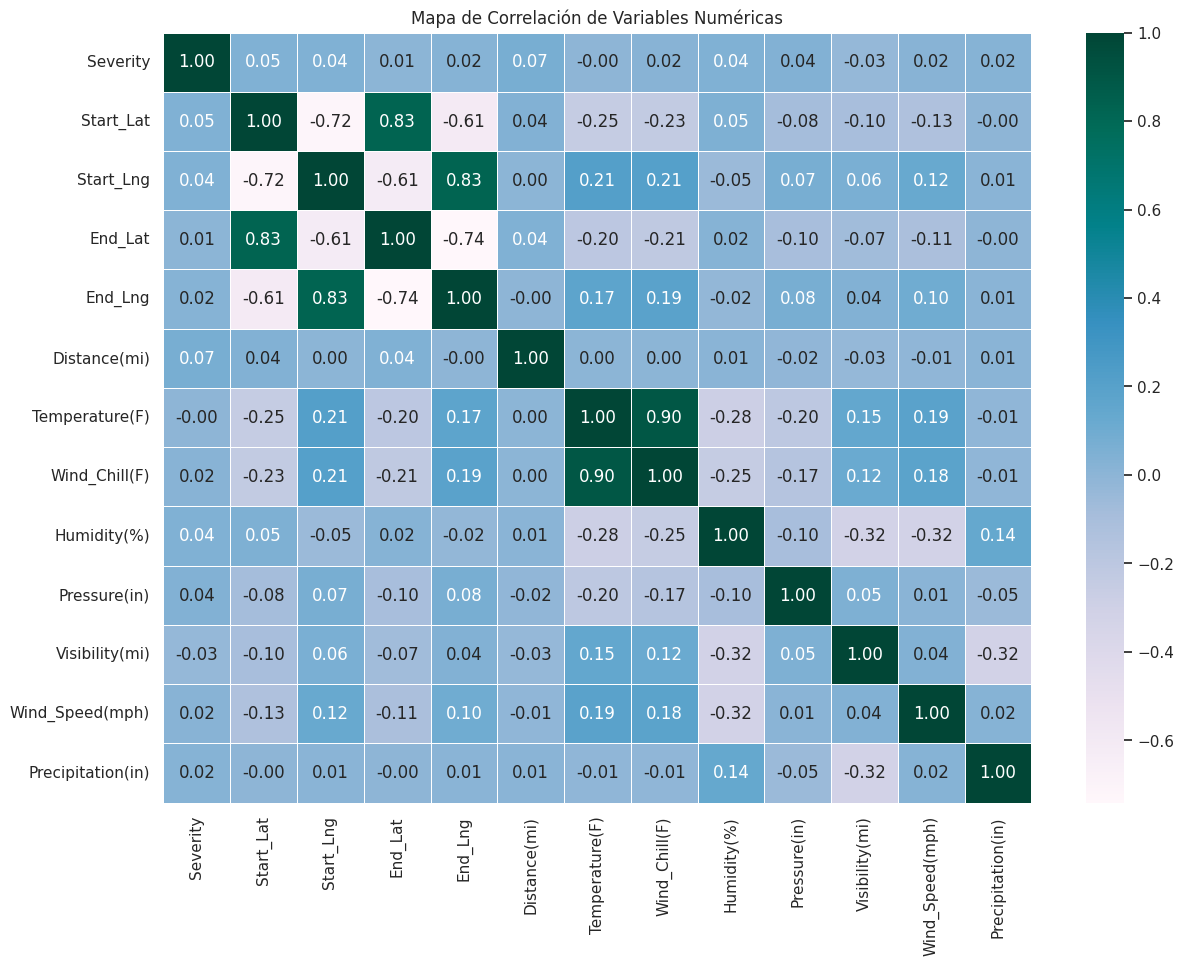

In [144]:
# Mapa de correlación
corr_matrix = df_label_encoded[number_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='PuBuGn', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Correlación de Variables Numéricas')
plt.show()

### 6.2 Análisis de Severidad

In [145]:
# Severidad promedio por hora del día
severity_hour = (traffic_accidents_raw
                 .groupby('Hour')['Severity']
                 .mean().reset_index(name='Severidad_Promedio'))

fig = px.line(severity_hour, x='Hour', y='Severidad_Promedio',
              markers=True, template='seaborn',
              title='Severidad Promedio por Hora del Día — Florida',
              labels={'Hour':'Hora','Severidad_Promedio':'Severidad Promedio'})
fig.update_traces(line_color='#e63946', line_width=2)
fig.update_layout(height=450, width=1000, font=dict(size=13))
fig.show()

hora_critica = severity_hour.loc[severity_hour['Severidad_Promedio'].idxmax()]
print(f"Hora con mayor severidad: {int(hora_critica['Hour'])}:00 hrs "
      f"(severidad: {hora_critica['Severidad_Promedio']:.2f})")

Hora con mayor severidad: 20:00 hrs (severidad: 2.23)


In [146]:
# Severidad por condición climática
severity_weather = (traffic_accidents_raw
                    .groupby('Weather_Condition')
                    .agg(
                        Severidad_Promedio=('Severity','mean'),
                        Total_Accidentes=('Severity','count')
                    )
                    .reset_index()
                    .query('Total_Accidentes >= 100')
                    .sort_values('Severidad_Promedio', ascending=False)
                    .head(15))

fig = px.bar(severity_weather, x='Severidad_Promedio', y='Weather_Condition',
             orientation='h', color='Severidad_Promedio',
             color_continuous_scale='YlOrRd',
             text=severity_weather['Severidad_Promedio'].round(2),
             template='seaborn',
             title='Top 15 Condiciones Climáticas por Severidad Promedio<br>'
                   '<sup>(condiciones con 100+ accidentes)</sup>')
fig.update_layout(height=550, width=1050, font=dict(size=13))
fig.show()

print('=== TOP 5 CONDICIONES CLIMÁTICAS POR SEVERIDAD ===')
print(severity_weather[['Weather_Condition','Severidad_Promedio',
                         'Total_Accidentes']].head(5).to_string(index=False))

=== TOP 5 CONDICIONES CLIMÁTICAS POR SEVERIDAD ===
           Weather_Condition  Severidad_Promedio  Total_Accidentes
      Thunderstorms and Rain                2.51               498
Heavy Thunderstorms and Rain                2.46               641
Light Thunderstorms and Rain                2.45              1130
                Thunderstorm                2.43              1531
                    Overcast                2.40             15900


In [147]:
# Severidad por condado
severity_county = (traffic_accidents_raw
                   .groupby('County')
                   .agg(
                       Severidad_Promedio=('Severity','mean'),
                       Total_Accidentes=('Severity','count')
                   )
                   .reset_index()
                   .query('Total_Accidentes >= 50')
                   .sort_values('Severidad_Promedio', ascending=False)
                   .head(20))

fig = px.bar(severity_county, x='County', y='Severidad_Promedio',
             color='Severidad_Promedio', color_continuous_scale='YlOrRd',
             text=severity_county['Severidad_Promedio'].round(2),
             template='seaborn',
             title='Top 20 Condados por Severidad Promedio — Florida<br>'
                   '<sup>(condados con 50+ accidentes)</sup>')
fig.update_layout(height=500, width=1100, font=dict(size=13))
fig.show()

In [148]:
# Resumen integrado: Ocurrencia + Severidad por condado
resumen_county = (traffic_accidents_raw
                  .groupby('County')
                  .agg(
                      Ocurrencias=('Severity','count'),
                      Severidad_Promedio=('Severity','mean')
                  )
                  .reset_index())

resumen_county['Riesgo_Ocurrencia'] = clasificar_riesgo(resumen_county['Ocurrencias'])
resumen_county['Nivel_Severidad']   = pd.cut(
    resumen_county['Severidad_Promedio'],
    bins=[0, 1.5, 2.0, 2.5, 4],
    labels=['Baja','Moderada','Alta','Crítica']
)

fig = px.scatter(resumen_county,
                 x='Ocurrencias', y='Severidad_Promedio',
                 color='Riesgo_Ocurrencia', size='Ocurrencias',
                 hover_name='County',
                 color_discrete_map=color_riesgo,
                 template='seaborn',
                 title='Relación Ocurrencia vs Severidad por Condado — Florida<br>'
                       '<sup>Cada punto es un condado. Tamaño = número de accidentes</sup>')
fig.update_layout(height=550, width=1000, font=dict(size=13))
fig.show()

print('=== PERFIL DE RIESGO COMPLETO POR CONDADO (Top 15) ===')
display(resumen_county.sort_values('Ocurrencias', ascending=False)
        .head(15)[['County','Ocurrencias','Riesgo_Ocurrencia',
                   'Severidad_Promedio','Nivel_Severidad']]
        .reset_index(drop=True))

=== PERFIL DE RIESGO COMPLETO POR CONDADO (Top 15) ===


,County,Ocurrencias,Riesgo_Ocurrencia,Severidad_Promedio,Nivel_Severidad
0,Miami-Dade,251601,Crítico,2.09,Alta
1,Orange,124321,Crítico,2.08,Alta
2,Broward,53865,Crítico,2.33,Alta
3,Hillsborough,52623,Crítico,2.20,Alta
4,Duval,41726,Crítico,2.40,Alta
5,Pinellas,41387,Crítico,2.06,Alta
6,Lee,34554,Crítico,2.06,Alta
7,Palm Beach,30931,Crítico,2.31,Alta
8,Manatee,22153,Crítico,2.09,Alta
9,Sarasota,20675,Crítico,2.09,Alta


---
## 7. Modelado Predictivo

### Setup del modelo

In [102]:
# ── MODELADO | Setup ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, accuracy_score)

### 🛠️ RandomForestClassifier

In [149]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, accuracy_score)

# 1. Dataset con encoding
df = df_label_encoded.copy()

# 2. Agregar Hour si no existe
if 'Hour' not in df.columns:
    df['Hour'] = pd.to_datetime(
        traffic_accidents_scaled['Start_Time'], errors='coerce'
    ).dt.hour

# 3. Seleccionar columnas relevantes
cols = [
    'Severity',
    # Geográficas
    'Start_Lat', 'Start_Lng', 'Street', 'City', 'County',
    # Infraestructura vial
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
    # Climáticas
    'Wind_Chill(F)', 'Temperature(F)', 'Humidity(%)',
    'Visibility(mi)', 'Wind_Speed(mph)',
    'Weather_Condition', 'Precipitation(in)',
    # Temporal
    'Hour'
]
df = df[cols].dropna()

# 4. Codificar Weather_Condition
df = pd.get_dummies(df, columns=['Weather_Condition'], drop_first=True)

# 5. Variable objetivo — 3 categorías
df['Target'] = pd.cut(
    df['Severity'],
    bins=[0, 1, 2, 4],
    labels=['Low', 'Moderate', 'High']
)
df = df.drop(columns=['Severity'])
df = df.dropna(subset=['Target'])

print('Distribución de la variable objetivo:')
print(df['Target'].value_counts())

# 6. X e y sin split aún
X = df.drop('Target', axis=1)
y = df['Target']

Distribución de la variable objetivo:
Target
Moderate    642070
High        116472
Low           7083
Name: count, dtype: int64


### 7.2 Balanceo de Clases

In [150]:
# Undersampling — igualar todas las clases al mínimo
print('Distribución antes del balanceo:')
print(y.value_counts())

min_class_count = y.value_counts().min()

df_balanced = pd.concat([X, y], axis=1)
df_balanced = (
    df_balanced
    .groupby('Target', group_keys=False, observed=True)
    .apply(lambda x: x.sample(n=min_class_count, random_state=42))
    .reset_index(drop=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

X = df_balanced.drop(columns=['Target'])
y = df_balanced['Target']

print(f'\nDistribución después del balanceo:')
print(y.value_counts())
print(f'\nTotal registros balanceados: {len(df_balanced):,}')

# Split 80/20 DESPUÉS del balanceo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTraining Set: {len(X_train):,} registros')
print(f'Test Set:     {len(X_test):,} registros')

Distribución antes del balanceo:
Target
Moderate    642070
High        116472
Low           7083
Name: count, dtype: int64

Distribución después del balanceo:
Target
Low         7083
Moderate    7083
High        7083
Name: count, dtype: int64

Total registros balanceados: 21,249

Training Set: 16,999 registros
Test Set:     4,250 registros


/tmp/ipykernel_586/2417571844.py:11: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



### 7.3 Random Forest

In [151]:
print('=' * 55)
print('           RANDOM FOREST CLASSIFIER')
print('=' * 55)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Validación cruzada
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=kf, scoring='accuracy')
print(f'\n📊 Validación Cruzada (5-Fold):')
print(f'   Scores:  {cv_scores_rf.round(4)}')
print(f'   Media:   {cv_scores_rf.mean():.4f}')
print(f'   Std:     {cv_scores_rf.std():.4f}')

# Entrenamiento y evaluación
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)

print(f'\n📋 Evaluación en Test Set:')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_rf))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))
print(f'ROC AUC:  {roc_auc_score(y_test, y_prob_rf, multi_class="ovr", average="weighted"):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')

           RANDOM FOREST CLASSIFIER

📊 Validación Cruzada (5-Fold):
   Scores:  [0.75   0.7653 0.7553 0.7588 0.7435]
   Media:   0.7546
   Std:     0.0075

📋 Evaluación en Test Set:
Confusion Matrix:
 [[1156  114  146]
 [ 130 1173  114]
 [ 304  180  933]]

Classification Report:
               precision    recall  f1-score   support

        High       0.73      0.82      0.77      1416
         Low       0.80      0.83      0.81      1417
    Moderate       0.78      0.66      0.71      1417

    accuracy                           0.77      4250
   macro avg       0.77      0.77      0.77      4250
weighted avg       0.77      0.77      0.77      4250

ROC AUC:  0.9065
Accuracy: 0.7675


### 7.4 Extra Trees

In [152]:
print('=' * 55)
print('           EXTRA TREES CLASSIFIER')
print('=' * 55)

et = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Validación cruzada
cv_scores_et = cross_val_score(et, X_train, y_train, cv=kf, scoring='accuracy')
print(f'\n📊 Validación Cruzada (5-Fold):')
print(f'   Scores:  {cv_scores_et.round(4)}')
print(f'   Media:   {cv_scores_et.mean():.4f}')
print(f'   Std:     {cv_scores_et.std():.4f}')

# Entrenamiento y evaluación
et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)
y_prob_et  = et.predict_proba(X_test)

print(f'\n📋 Evaluación en Test Set:')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_et))
print('\nClassification Report:\n', classification_report(y_test, y_pred_et))
print(f'ROC AUC:  {roc_auc_score(y_test, y_prob_et, multi_class="ovr", average="weighted"):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_et):.4f}')

           EXTRA TREES CLASSIFIER

📊 Validación Cruzada (5-Fold):
   Scores:  [0.7271 0.7347 0.7324 0.7376 0.7243]
   Media:   0.7312
   Std:     0.0049

📋 Evaluación en Test Set:
Confusion Matrix:
 [[1125  116  175]
 [ 152 1143  122]
 [ 335  181  901]]

Classification Report:
               precision    recall  f1-score   support

        High       0.70      0.79      0.74      1416
         Low       0.79      0.81      0.80      1417
    Moderate       0.75      0.64      0.69      1417

    accuracy                           0.75      4250
   macro avg       0.75      0.75      0.74      4250
weighted avg       0.75      0.75      0.74      4250

ROC AUC:  0.8925
Accuracy: 0.7456


### 7.5 Comparación de Modelos + Feature Importance

In [153]:
print('=' * 55)
print('         COMPARACIÓN DE MODELOS')
print('=' * 55)

results_df = pd.DataFrame({
    'Modelo':        ['Random Forest', 'Extra Trees'],
    'CV Media':      [cv_scores_rf.mean(), cv_scores_et.mean()],
    'CV Std':        [cv_scores_rf.std(),  cv_scores_et.std()],
    'Test Accuracy': [accuracy_score(y_test, y_pred_rf),
                      accuracy_score(y_test, y_pred_et)],
    'ROC AUC':       [
        roc_auc_score(y_test, y_prob_rf, multi_class='ovr', average='weighted'),
        roc_auc_score(y_test, y_prob_et, multi_class='ovr', average='weighted')
    ]
}).round(4)

display(results_df)

# Mejor modelo por ROC AUC
best_idx   = results_df['ROC AUC'].idxmax()
best_name  = results_df.loc[best_idx, 'Modelo']
best_model = rf if best_idx == 0 else et
print(f'\n✅ Mejor modelo: {best_name}')

# Feature Importance
feat_importance = (pd.DataFrame({
    'Feature':    X.columns,
    'Importance': best_model.feature_importances_
})
.sort_values('Importance', ascending=False)
.head(15))

fig = px.bar(feat_importance, x='Importance', y='Feature',
             orientation='h',
             color='Importance', color_continuous_scale='PuBuGn',
             template='seaborn',
             title=f'Top 15 Variables más Importantes — {best_name}')
fig.update_layout(height=600, width=1000, font=dict(size=13))
fig.show()

         COMPARACIÓN DE MODELOS


,Modelo,CV Media,CV Std,Test Accuracy,ROC AUC
0,Random Forest,0.75,0.01,0.77,0.91
1,Extra Trees,0.73,0.00,0.75,0.89



✅ Mejor modelo: Random Forest
